In [25]:
!pip install timm -q
import os, time, tarfile, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

IMG_SIZE     = 224
SEEDS        = [0, 42, 67]
RETRAIN_CNNS = False
EPOCHS       = 40
BATCH_SIZE   = 48
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-5
NUM_WORKERS  = 2

VIT_NAME     = "vit_small_patch14_dinov2.lvd142m"
VIT_EPOCHS   = 3
VIT_LR       = 1e-3

TRANSFER_N   = 1500
TRANSFER_BS  = 32
EPS_MATRIX   = 8 / 255
PGD_STEPS    = 10
CONSISTENCY_ATTACK = "fgsm"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

CKPT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
VIT_CKPT_NAME = "vit_imagewoof.pt"

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Device: cuda


In [6]:
def locate_imagewoof():
    work = Path("/kaggle/working/data") if Path("/kaggle/working").exists() else Path("./data")
    work.mkdir(parents=True, exist_ok=True)
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("Папка /kaggle/input не найдена -- добавьте датасет через Add Data.")
    for p in sorted(input_root.rglob("train")):
        if not p.is_dir():
            continue
        parent = p.parent
        for val_name in ("val", "validation", "test"):
            if (parent / val_name).is_dir():
                return parent, val_name
    for p in [q for ext in ("*.tgz", "*.tar.gz", "*.zip") for q in input_root.rglob(ext)]:
        if p.suffix == ".zip":
            import zipfile
            with zipfile.ZipFile(p) as z: z.extractall(work)
        else:
            with tarfile.open(p) as tar: tar.extractall(work)
        for root, dirs, files in os.walk(work):
            dl = [d.lower() for d in dirs]
            if "train" in dl:
                rp = Path(root)
                for vn in ("val", "validation", "test"):
                    if vn in dl:
                        return rp, dirs[dl.index(vn)]
    raise RuntimeError("Не нашёл train/ + val в /kaggle/input.")

DATA_ROOT, VAL_DIRNAME = locate_imagewoof()

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_set = torchvision.datasets.ImageFolder(DATA_ROOT / "train", transform=train_tf)
val_set   = torchvision.datasets.ImageFolder(DATA_ROOT / VAL_DIRNAME, transform=eval_tf)
if train_set.classes != val_set.classes:
    raise RuntimeError("классы train и val не совпадают")
CLASSES = train_set.classes
NUM_CLASSES = len(CLASSES)

val_loader = DataLoader(val_set, batch_size=64, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

n_sub = min(TRANSFER_N, len(val_set))
transfer_loader = DataLoader(Subset(val_set, list(range(n_sub))), batch_size=TRANSFER_BS,
                             shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"train {len(train_set)} | val {len(val_set)} | классов {NUM_CLASSES} | размер {IMG_SIZE}")
print(f"подвыборка для матрицы: {n_sub}")

/tmp/ipykernel_108/1486724269.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(p) as tar: tar.extractall(work)


train 9025 | val 3929 | классов 10 | размер 224
подвыборка для матрицы: 1500


In [7]:
class NormalizeCNN(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return (x - self.mean) / self.std


class CNNWrapper(nn.Module):
    def __init__(self, backbone, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        super().__init__()
        self.normalize = NormalizeCNN(mean, std)
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(self.normalize(x))


class NormalizedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1))
    def forward(self, x):
        return self.model((x - self.mean) / self.std)


def build_resnet18():
    net = torchvision.models.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
    return CNNWrapper(net).to(DEVICE)


def build_vgg():
    net = torchvision.models.vgg11_bn(weights=None)
    net.classifier[6] = nn.Linear(net.classifier[6].in_features, NUM_CLASSES)
    return CNNWrapper(net).to(DEVICE)


def build_vit():
    base = timm.create_model(VIT_NAME, pretrained=True, num_classes=NUM_CLASSES,
                             img_size=IMG_SIZE, dynamic_img_size=True)
    return NormalizedModel(base).to(DEVICE)

In [8]:
@torch.no_grad()
def clean_accuracy(net, loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (net(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


def find_ckpt(filename):
    local = CKPT_DIR / filename
    if local.exists():
        return local
    root = Path("/kaggle/input")
    if root.exists():
        hits = list(root.rglob(filename))
        if hits:
            return hits[0]
    return None


def train_cnn(build_fn, seed, tag):
    filename = f"{tag}.pt"
    found = find_ckpt(filename)
    if found is not None and not RETRAIN_CNNS:
        print(f"{tag}: загружаю чекпоинт {found}")
        model = build_fn()
        model.load_state_dict(torch.load(found, map_location=DEVICE)["state_dict"])
        model.eval()
        return model

    print(f"{tag}: обучаю на {IMG_SIZE}px (seed {seed})")
    set_seed(seed)
    model = build_fn()
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM,
                                weight_decay=WEIGHT_DECAY, nesterov=True)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader))
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    best_val = 0.0
    save_path = str(CKPT_DIR / filename)
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
        va = clean_accuracy(model, val_loader)
        if va > best_val:
            best_val = va
            torch.save({"state_dict": model.state_dict(), "tag": tag, "val_acc": va}, save_path)
    print(f"{tag}: best val {best_val*100:.2f}%")
    model.load_state_dict(torch.load(save_path, map_location=DEVICE)["state_dict"])
    model.eval()
    return model

In [10]:
def get_vit():
    found = find_ckpt(VIT_CKPT_NAME)
    if found is not None:
        print(f"ViT: загружаю чекпоинт коллеги {found}")
        ck = torch.load(found, map_location=DEVICE)
        model = build_vit()
        model.load_state_dict(ck["state_dict"])
        model.eval()
        return model

    print(f"ViT: чекпоинт не найден, воспроизвожу сетап коллеги (DINOv2 + head-only fine-tune)")
    set_seed(0)
    model = build_vit()
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    optimizer = torch.optim.AdamW(model.model.head.parameters(), lr=VIT_LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(VIT_EPOCHS):
        model.train()
        running = 0.0
        for images, labels in tqdm(train_loader, desc=f"ViT epoch {epoch+1}/{VIT_EPOCHS}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item()
        print(f"  loss {running/len(train_loader):.4f}")

    save_path = str(CKPT_DIR / VIT_CKPT_NAME)
    torch.save({"state_dict": model.state_dict(), "timm_name": VIT_NAME,
                "num_classes": NUM_CLASSES, "img_size": IMG_SIZE}, save_path)
    print(f"ViT: сохранил {save_path}")
    model.eval()
    return model

In [27]:
import zipfile, shutil

REPACK_DIR = Path("/kaggle/working/repacked")
REPACK_DIR.mkdir(parents=True, exist_ok=True)


def is_torch_dir(p):
    return p.is_dir() and (p / "data.pkl").exists() or (p.is_dir() and (p / "byteorder").exists())


def repack_torch_dir(folder):
    out = REPACK_DIR / (folder.name + ".pth")
    if out.exists():
        return out
    files = [f for f in folder.rglob("*") if f.is_file()]
    with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as zf:
        for f in files:
            arcname = folder.name + "/" + str(f.relative_to(folder))
            zf.write(f, arcname)
    return out


def find_resnet_dir(seed):
    root = Path("/kaggle/input")
    for p in root.rglob("*"):
        low = str(p).lower()
        if "vit" in low:
            continue
        if p.is_dir() and (p / "byteorder").exists():
            if f"seed{seed}" in low or f"seed_{seed}" in low or f"s{seed}" in low:
                return p
    return None


def load_state_from_ckpt(obj):
    if isinstance(obj, dict) and "state_dict" in obj:
        return obj["state_dict"]
    if isinstance(obj, dict) and "model_state_dict" in obj:
        return obj["model_state_dict"]
    return obj


def strip_prefix(sd, anchor="conv1.weight"):
    prefix = ""
    for k in sd:
        if k.endswith(anchor) and "layer" not in k and "downsample" not in k:
            prefix = k[: -len(anchor)]
            break
    bare = {}
    for k, v in sd.items():
        if not k.startswith(prefix):
            continue
        nk = k[len(prefix):]
        if nk in ("mean", "std") or nk.startswith("normalize."):
            continue
        bare[nk] = v
    return bare


class WrappedForInference(nn.Module):
    def __init__(self, net, mean=IMAGENET_MEAN, std=IMAGENET_STD):
        super().__init__()
        self.net = net
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return self.net((x - self.mean) / self.std)


def load_resnet_seed(seed):
    folder = find_resnet_dir(seed)
    if folder is None:
        raise FileNotFoundError(f"ResNet seed {seed}: папка-чекпоинт не найдена")
    packed = repack_torch_dir(folder)
    sd = load_state_from_ckpt(torch.load(packed, map_location=DEVICE))
    bare = strip_prefix(sd, "conv1.weight")
    net = torchvision.models.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
    net.load_state_dict(bare, strict=True)
    model = WrappedForInference(net).to(DEVICE).eval()
    print(f"ResNet18-s{seed}: {folder}  ->  {packed}")
    return model


MODELS = {}
for s in SEEDS:
    try:
        MODELS[f"ResNet18-s{s}"] = load_resnet_seed(s)
    except Exception as e:
        print(f"!!! ResNet s{s} УПАЛ: {type(e).__name__}: {e}")

try:
    MODELS["ViT"] = load_vit_seed(SEEDS[0])
except Exception as e:
    print(f"!!! ViT УПАЛ: {type(e).__name__}: {e}")

print("\nЗагружено узлов:", list(MODELS.keys()))
for name, m in MODELS.items():
    try:
        print(f"  {name:>14}: {clean_accuracy(m, val_loader)*100:5.2f}%")
    except Exception as e:
        print(f"  {name}: ошибка на точности — {e}")

def load_vit_seed(seed):
    root = Path("/kaggle/input")
    path = None
    for p in root.rglob("*.pth"):
        if "vit" in str(p).lower() and f"seed_{seed}" in str(p).lower():
            path = p
            break
    if path is None:
        for p in root.rglob("*.pth"):
            if "vit" in str(p).lower():
                path = p
                break
    if path is None:
        raise FileNotFoundError("ViT .pth не найден")

    sd = load_state_from_ckpt(torch.load(path, map_location=DEVICE))
    prefix = "model." if any(k.startswith("model.") for k in sd) else ""
    pos = sd[prefix + "pos_embed"]
    proj = sd[prefix + "patch_embed.proj.weight"]
    native = proj.shape[-1] * int(round((pos.shape[1] - 1) ** 0.5))
    ncls = sd[prefix + "head.weight"].shape[0]

    base = timm.create_model(VIT_NAME, pretrained=False, num_classes=ncls,
                             img_size=native, dynamic_img_size=True)
    model = NormalizedModel(base).to(DEVICE)
    model.load_state_dict(sd)
    model.eval()
    print(f"ViT: {path} (native {native})")
    return model

ResNet18-s0: /kaggle/input/datasets/ulianaandrosova/resnt-weightss0/resnet18_imagewoof_seed0  ->  /kaggle/working/repacked/resnet18_imagewoof_seed0.pth
ResNet18-s42: /kaggle/input/datasets/ulianaandrosova/resnt-imgwfs42/resnet18_imagewoof_seed42  ->  /kaggle/working/repacked/resnet18_imagewoof_seed42.pth
ResNet18-s67: /kaggle/input/datasets/ulianaandrosova/resnt-imgwfs67/resnet18_imagewoof_seed67  ->  /kaggle/working/repacked/resnet18_imagewoof_seed67.pth

Загружено узлов: ['ResNet18-s0', 'ResNet18-s42', 'ResNet18-s67', 'ViT']
     ResNet18-s0: 80.05%
    ResNet18-s42: 80.55%
    ResNet18-s67: 79.99%
  ViT: ошибка на точности — 'NoneType' object has no attribute 'eval'


In [29]:
MODELS["ViT"] = load_vit_seed(SEEDS[0])
print("ViT точность:", clean_accuracy(MODELS["ViT"], val_loader) * 100)

ViT: /kaggle/input/datasets/ulianaandrosova/vit-weightsw/vit_imagewoof_seed_0.pth (native 224)
ViT точность: 95.13871214049377


In [30]:
import torch
p = "/kaggle/input/datasets/ulianaandrosova/vit-weightsw/vit_imagewoof_seed_0.pth"
ck = torch.load(p, map_location="cpu")
sd = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
print("тип:", type(ck))
if isinstance(ck, dict):
    print("мета-ключи:", [k for k in ck if k != "state_dict"][:10])
print("префикс model.:", any(k.startswith("model.") for k in sd))
for k, v in sd.items():
    if any(t in k for t in ("pos_embed", "patch_embed.proj.weight", "head.weight", "cls_token")):
        print(k, tuple(v.shape))

тип: <class 'collections.OrderedDict'>
мета-ключи: ['mean', 'std', 'model.cls_token', 'model.pos_embed', 'model.patch_embed.proj.weight', 'model.patch_embed.proj.bias', 'model.blocks.0.norm1.weight', 'model.blocks.0.norm1.bias', 'model.blocks.0.attn.qkv.weight', 'model.blocks.0.attn.qkv.bias']
префикс model.: True
model.cls_token (1, 1, 384)
model.pos_embed (1, 257, 384)
model.patch_embed.proj.weight (384, 3, 14, 14)
model.head.weight (10, 384)


In [31]:
def fgsm(net, x, y, eps):
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(net(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    return (x + eps * grad.sign()).clamp(0, 1).detach()


def pgd(net, x, y, eps, alpha, steps):
    x_orig = x.clone().detach()
    x_adv = (x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(net(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = (x_orig + (x_adv - x_orig).clamp(-eps, eps)).clamp(0, 1).detach()
    return x_adv

In [32]:
def transfer_matrix(attack_fn, loader, models):
    names = list(models.keys())
    corr = {src: {tgt: 0 for tgt in names} for src in names}
    total = 0
    for x, y in tqdm(loader, desc="матрица"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        total += y.size(0)
        for src in names:
            x_adv = attack_fn(models[src], x, y)
            with torch.no_grad():
                for tgt in names:
                    corr[src][tgt] += (models[tgt](x_adv).argmax(1) == y).sum().item()
    mat = np.array([[corr[s][t] / total * 100 for t in names] for s in names])
    return mat, names


fgsm_fn = lambda net, x, y: fgsm(net, x, y, EPS_MATRIX)
pgd_fn  = lambda net, x, y: pgd(net, x, y, EPS_MATRIX, EPS_MATRIX / 4, PGD_STEPS)

print(f"eps = {EPS_MATRIX*255:.0f}/255, {n_sub} картинок")
mat_fgsm, NAMES = transfer_matrix(fgsm_fn, transfer_loader, MODELS)
mat_pgd,  _     = transfer_matrix(pgd_fn,  transfer_loader, MODELS)

eps = 8/255, 1500 картинок


матрица: 100%|██████████| 47/47 [04:33<00:00,  5.82s/it]


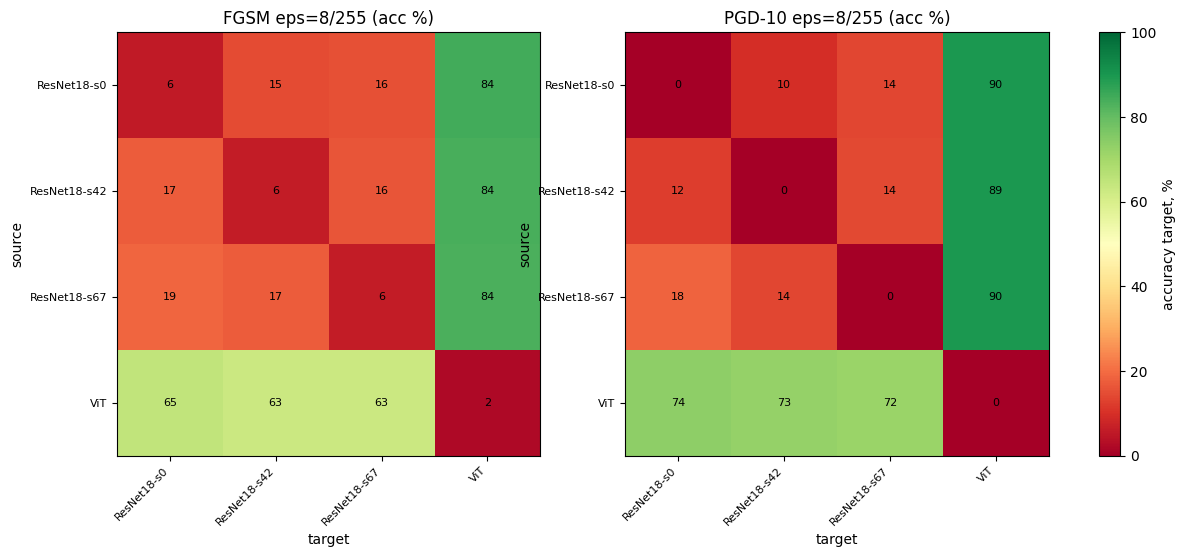

Ниже accuracy = сильнее перенос. Диагональ = white-box.


In [33]:
def plot_matrix(mat, names, title, ax):
    im = ax.imshow(mat, cmap="RdYlGn", vmin=0, vmax=100)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("target"); ax.set_ylabel("source")
    ax.set_title(title)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center", fontsize=8)
    return im

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
plot_matrix(mat_fgsm, NAMES, f"FGSM eps={EPS_MATRIX*255:.0f}/255 (acc %)", ax[0])
im1 = plot_matrix(mat_pgd, NAMES, f"PGD-{PGD_STEPS} eps={EPS_MATRIX*255:.0f}/255 (acc %)", ax[1])
fig.colorbar(im1, ax=ax, fraction=0.025, label="accuracy target, %")
plt.show()

print("Ниже accuracy = сильнее перенос. Диагональ = white-box.")

In [35]:
def transfer_rate(mat, names, src_group, tgt_group):
    vals = [100 - mat[i, j]
            for i, s in enumerate(names) for j, t in enumerate(names)
            if s in src_group and t in tgt_group and s != t]
    return np.mean(vals) if vals else float("nan")


cnn_names = [n for n in NAMES if n != "ViT"]
if "ViT" in NAMES:
    for label, mat in [("FGSM", mat_fgsm), ("PGD", mat_pgd)]:
        c2v = transfer_rate(mat, NAMES, cnn_names, ["ViT"])
        v2c = transfer_rate(mat, NAMES, ["ViT"], cnn_names)
        print(f"{label}: CNN->ViT {c2v:5.1f}%  |  ViT->CNN {v2c:5.1f}%")
    print("\nCNN->ViT < ViT->CNN -> асимметрия Benz подтверждается.")
    print(f"CNN->CNN (FGSM) для контекста: {transfer_rate(mat_fgsm, NAMES, cnn_names, cnn_names):.1f}%")

FGSM: CNN->ViT  16.0%  |  ViT->CNN  36.6%
PGD: CNN->ViT  10.4%  |  ViT->CNN  27.4%

CNN->ViT < ViT->CNN -> асимметрия Benz подтверждается.
CNN->CNN (FGSM) для контекста: 83.3%


In [36]:
@torch.no_grad()
def correctness_vector(net, loader):
    net.eval()
    out = []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out.append((net(x).argmax(1) == y).cpu())
    return torch.cat(out).numpy().astype(bool)


def cohen_kappa(c1, c2):
    p_obs = np.mean(c1 == c2)
    p1, p2 = c1.mean(), c2.mean()
    p_chance = p1 * p2 + (1 - p1) * (1 - p2)
    return 0.0 if (1 - p_chance) == 0 else (p_obs - p_chance) / (1 - p_chance)


corr_vecs = {name: correctness_vector(m, transfer_loader) for name, m in MODELS.items()}

print("Error consistency (каппа):")
consistency = {}
for i, a in enumerate(NAMES):
    for b in NAMES[i+1:]:
        k = cohen_kappa(corr_vecs[a], corr_vecs[b])
        consistency[(a, b)] = k
        print(f"  {a:>14} <-> {b:<14}: {k:.3f}")

Error consistency (каппа):
     ResNet18-s0 <-> ResNet18-s42  : 0.657
     ResNet18-s0 <-> ResNet18-s67  : 0.616
     ResNet18-s0 <-> ViT           : 0.214
    ResNet18-s42 <-> ResNet18-s67  : 0.676
    ResNet18-s42 <-> ViT           : 0.216
    ResNet18-s67 <-> ViT           : 0.199


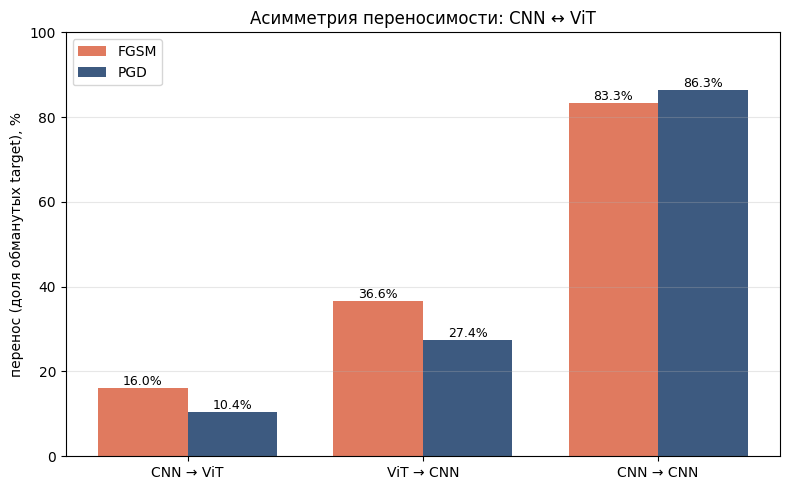

Чем выше столбик — тем сильнее перенос. CNN→ViT ниже ViT→CNN = асимметрия Benz.
CNN→CNN — самый высокий: внутри одной архитектуры атаки переносятся легче всего.


In [38]:
groups = {"CNN": cnn_names, "ViT": ["ViT"]}
directions = [("CNN", "ViT"), ("ViT", "CNN"), ("CNN", "CNN")]
dir_labels = ["CNN → ViT", "ViT → CNN", "CNN → CNN"]

fgsm_vals, pgd_vals = [], []
for src, tgt in directions:
    fgsm_vals.append(transfer_rate(mat_fgsm, NAMES, groups[src], groups[tgt]))
    pgd_vals.append(transfer_rate(mat_pgd, NAMES, groups[src], groups[tgt]))

x = np.arange(len(directions))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, fgsm_vals, w, label="FGSM", color="#e07a5f")
b2 = ax.bar(x + w/2, pgd_vals, w, label="PGD", color="#3d5a80")
ax.bar_label(b1, fmt="%.1f%%", fontsize=9)
ax.bar_label(b2, fmt="%.1f%%", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(dir_labels)
ax.set_ylabel("перенос (доля обманутых target), %")
ax.set_title("Асимметрия переносимости: CNN ↔ ViT")
ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

print("Чем выше столбик — тем сильнее перенос. CNN→ViT ниже ViT→CNN = асимметрия Benz.")
print("CNN→CNN — самый высокий: внутри одной архитектуры атаки переносятся легче всего.")

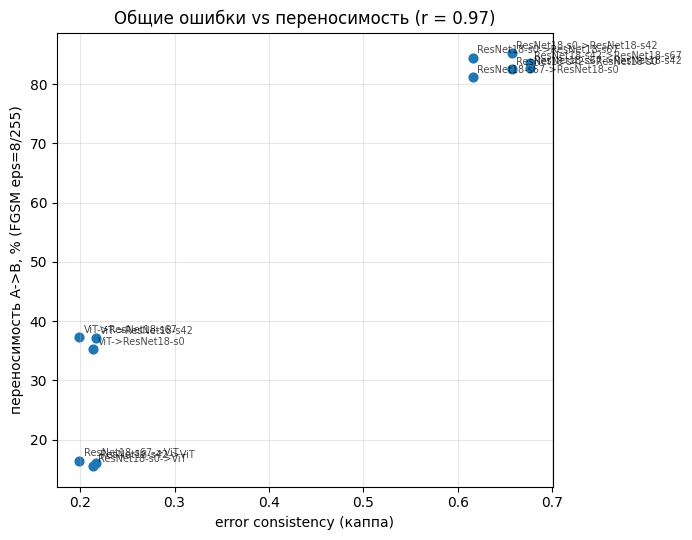

Pearson r = 0.965
Положительная корреляция -> похожие ошибки идут с высокой переносимостью.
Вертикальный разброс при одном x -- асимметрия переноса A->B vs B->A.


In [37]:
attack_mat = mat_fgsm if CONSISTENCY_ATTACK == "fgsm" else mat_pgd

xs, ys, labels = [], [], []
for i, a in enumerate(NAMES):
    for j, b in enumerate(NAMES):
        if a == b:
            continue
        pair = (a, b) if (a, b) in consistency else (b, a)
        if pair not in consistency:
            continue
        xs.append(consistency[pair])
        ys.append(100 - attack_mat[i, j])
        labels.append(f"{a}->{b}")

xs, ys = np.array(xs), np.array(ys)
r = np.corrcoef(xs, ys)[0, 1] if len(xs) > 1 else float("nan")

plt.figure(figsize=(7, 5.5))
plt.scatter(xs, ys, s=40)
for x, y, lab in zip(xs, ys, labels):
    plt.annotate(lab, (x, y), fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.xlabel("error consistency (каппа)")
plt.ylabel(f"переносимость A->B, % ({CONSISTENCY_ATTACK.upper()} eps={EPS_MATRIX*255:.0f}/255)")
plt.title(f"Общие ошибки vs переносимость (r = {r:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.3f}")
print("Положительная корреляция -> похожие ошибки идут с высокой переносимостью.")
print("Вертикальный разброс при одном x -- асимметрия переноса A->B vs B->A.")

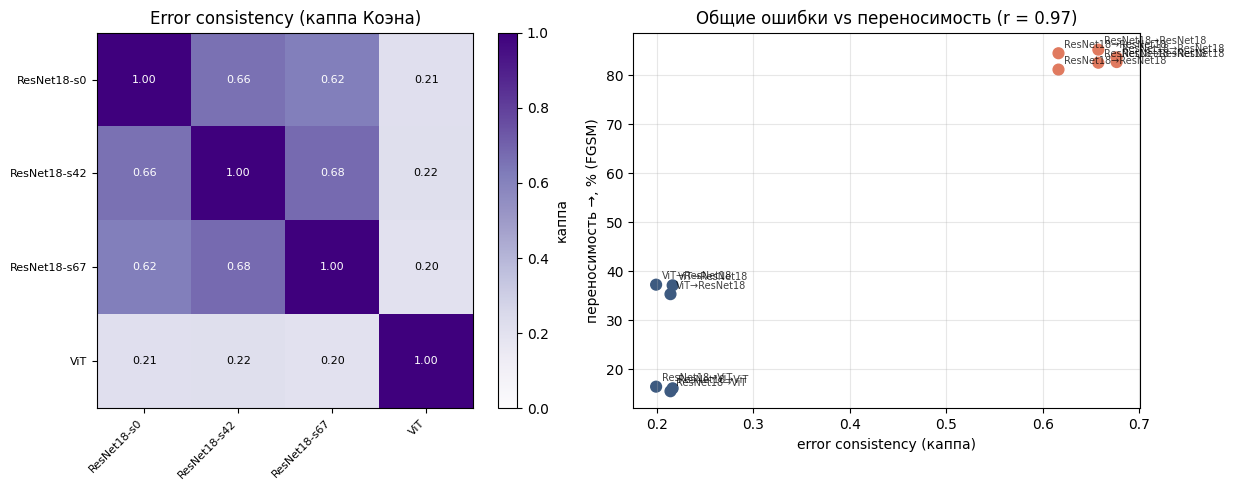

Pearson r = 0.965
Синие точки — пары с ViT (низкая каппа, низкий перенос).
Оранжевые — CNN↔CNN (высокая каппа, высокий перенос). Точки идут по диагонали = связь есть.


In [39]:
n = len(NAMES)
kappa_mat = np.eye(n)
for i, a in enumerate(NAMES):
    for j, b in enumerate(NAMES):
        if i == j:
            continue
        pair = (a, b) if (a, b) in consistency else (b, a)
        kappa_mat[i, j] = consistency.get(pair, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

im = ax[0].imshow(kappa_mat, cmap="Purples", vmin=0, vmax=1)
ax[0].set_xticks(range(n)); ax[0].set_xticklabels(NAMES, rotation=45, ha="right", fontsize=8)
ax[0].set_yticks(range(n)); ax[0].set_yticklabels(NAMES, fontsize=8)
ax[0].set_title("Error consistency (каппа Коэна)")
for i in range(n):
    for j in range(n):
        ax[0].text(j, i, f"{kappa_mat[i,j]:.2f}", ha="center", va="center",
                   fontsize=8, color="white" if kappa_mat[i,j] > 0.5 else "black")
fig.colorbar(im, ax=ax[0], fraction=0.046, label="каппа")

attack_mat = mat_fgsm if CONSISTENCY_ATTACK == "fgsm" else mat_pgd
xs, ys, labels = [], [], []
for i, a in enumerate(NAMES):
    for j, b in enumerate(NAMES):
        if a == b:
            continue
        pair = (a, b) if (a, b) in consistency else (b, a)
        if pair not in consistency:
            continue
        xs.append(consistency[pair])
        ys.append(100 - attack_mat[i, j])
        labels.append(f"{a[:8]}→{b[:8]}")

xs, ys = np.array(xs), np.array(ys)
r = np.corrcoef(xs, ys)[0, 1] if len(xs) > 1 else float("nan")
colors = ["#3d5a80" if "ViT" in lab else "#e07a5f" for lab in labels]
ax[1].scatter(xs, ys, c=colors, s=60)
for x_, y_, lab in zip(xs, ys, labels):
    ax[1].annotate(lab, (x_, y_), fontsize=7, alpha=0.75,
                   xytext=(4, 4), textcoords="offset points")
ax[1].set_xlabel("error consistency (каппа)")
ax[1].set_ylabel(f"переносимость →, % ({CONSISTENCY_ATTACK.upper()})")
ax[1].set_title(f"Общие ошибки vs переносимость (r = {r:.2f})")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Pearson r = {r:.3f}")
print("Синие точки — пары с ViT (низкая каппа, низкий перенос).")
print("Оранжевые — CNN↔CNN (высокая каппа, высокий перенос). Точки идут по диагонали = связь есть.")